In [1]:
### Les imports nécessaires
# Pour la manipulation de tableaux et Dataframes
import numpy as np
import pandas as pd

# Pour la visualisation des performances
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Pour instancier une couche Dense et modèle séquentiel
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

from tensorflow.keras.callbacks import EarlyStopping

In [2]:
## Chargement du Dataset
from sklearn.datasets import load_wine
wine = load_wine(as_frame=True)

## Analyse du dataset
display(wine.data.head())
print(wine.data.info())
print(wine.data.describe())

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [3]:
# Séparation X (features), y (target)
X = wine.data
y = wine.target

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
## Version propre (best practice)
# Split train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Split train / validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [5]:
# Etape 1 : Définition de l’architecture du modèle
model = Sequential()

model.add(Input(shape=(13,)))

model.add(Dense(units=10, activation="tanh"))
model.add(Dense(units=8, activation="tanh"))
model.add(Dense(units=6, activation="tanh"))
model.add(Dense(units=3, activation="softmax"))

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 303 (1.18 KB)

 Trainable params: 303 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Etape 2 : Compilation du modèle
model.compile(loss="sparse_categorical_crossentropy",
             optimizer="adam",
             metrics=["accuracy"])

In [7]:
# Etape 3 : Entraînement du modèle
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=500,
    batch_size=32,
    validation_data=(X_val_scaled, y_val),
    shuffle=True,
    callbacks=[early_stop]
)

Epoch 1/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.6063 - loss: 0.9347 - val_accuracy: 0.5333 - val_loss: 0.9603
Epoch 2/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6378 - loss: 0.8864 - val_accuracy: 0.5333 - val_loss: 0.9123
Epoch 3/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6850 - loss: 0.8410 - val_accuracy: 0.6000 - val_loss: 0.8677
Epoch 4/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7402 - loss: 0.7995 - val_accuracy: 0.6667 - val_loss: 0.8251
Epoch 5/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7559 - loss: 0.7616 - val_accuracy: 0.7333 - val_loss: 0.7851
Epoch 6/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7953 - loss: 0.7258 - val_accuracy: 0.7333 - val_loss: 0.7474
Epoch 7/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8268 - loss: 0.6917 - val_accuracy: 0.8667 - val_loss: 0.7131
Epoch 8/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8583 - loss: 0.6610 - val_accuracy: 0.8667 - val_loss:

In [8]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9722 - loss: 0.1358
Test accuracy: 0.9722
Test loss: 0.1358


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       1.00      0.93      0.96        14
           2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



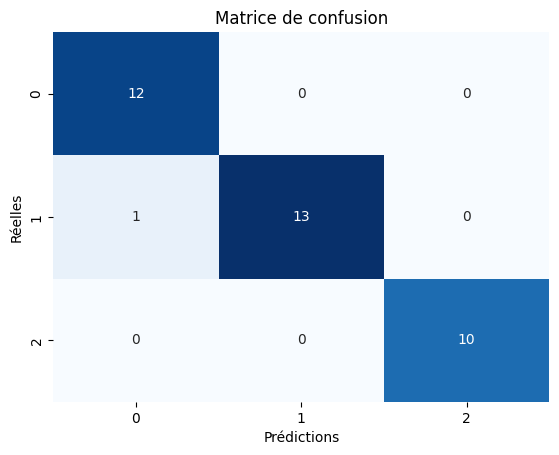

In [11]:
test_prob = model.predict(X_test_scaled)
test_pred = np.argmax(test_prob, axis=1)

from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_test, test_pred))
sns.heatmap(confusion_matrix(y_test, test_pred), cmap="Blues", annot=True, cbar=False)
plt.xlabel("Prédictions")
plt.ylabel("Réelles")
plt.title("Matrice de confusion")
plt.show()

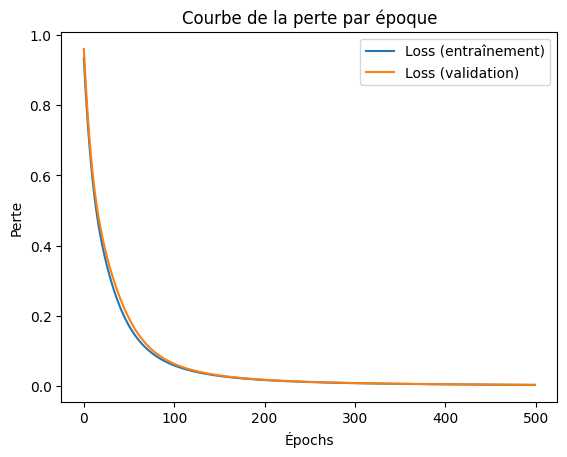

In [12]:
plt.figure()
plt.plot(history.history['loss'], label='Loss (entraînement)')
plt.plot(history.history['val_loss'], label='Loss (validation)')
plt.title('Courbe de la perte par époque')
plt.xlabel('Épochs')
plt.ylabel('Perte')
plt.legend()
plt.show()

In [6]:
# from sklearn.pipeline import Pipeline
# from sklearn.model_selection import cross_val_score, StratifiedKFold
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LogisticRegression

## Version pro (recommandée en production)
# Pipeline
#pipe = Pipeline([
#    ("scaler", StandardScaler()),
#    ("model", LogisticRegression(max_iter=200))
#])
#
# Cross-validation (stratifiée)
#cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#scores = cross_val_score(pipe, X, y, cv=cv)

#print("Accuracy par fold:", scores)
# print("Accuracy moyenne:", scores.mean())

In [ ]:
# Version encore plus pro : GridSearchCV
#from sklearn.model_selection import GridSearchCV

#pipe = Pipeline([
#    ("scaler", StandardScaler()),
#    ("model", LogisticRegression(max_iter=200))
#])

#param_grid = {
#    "model__C": [0.1, 1, 10],
#    "model__penalty": ["l2"]
#}

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#grid = GridSearchCV(
#    pipe,
#    param_grid=param_grid,
#    cv=cv,
#    scoring="accuracy"
#)

#grid.fit(X, y)

#print("Best params:", grid.best_params_)
#print("Best score:", grid.best_score_)